In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

# Import linear regression
from sklearn.linear_model import LinearRegression

# Import metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [2]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

--2026-10-05 16:51:03--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv’

car_fuel_efficiency 100%[===================>] 853.70K  --.-KB/s    in 0.02s   

2026-10-05 16:51:03 (38.9 MB/s) - ‘car_fuel_efficiency.csv’ saved [874188/874188]



In [4]:
# Read the car_fuel_efficiency.csv file
df = pd.read_csv('car_fuel_efficiency.csv')[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

In [5]:
df.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='object')

/tmp/ipykernel_770/630127314.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['fuel_efficiency_mpg'])


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Density'>

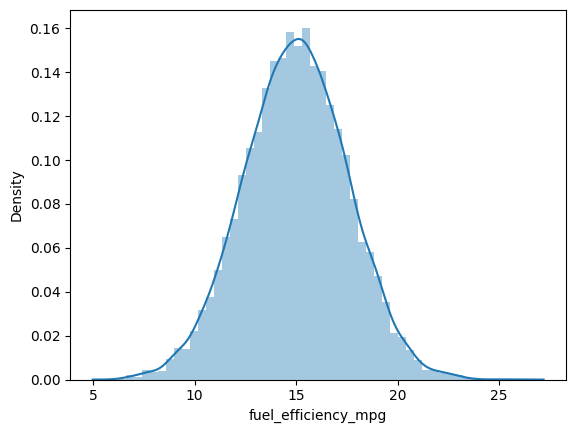

In [6]:
# Use seaborn to determine the length of the tail for fuel_efficiency_mpg
sns.distplot(df['fuel_efficiency_mpg'])

In [7]:
# Find out which column has missing values
missing_values_columns = []

for col in df.columns:
  # See if the column has missing values
  if df[col].isnull().any():
    missing_values_columns.append(col)

print(f"Q1. This column has missing values: {missing_values_columns[0]}")

Q1. This column has missing values: horsepower


In [8]:
# Determine the median for "horsepower"
horsepower_median = df['horsepower'].median()
print(f"Q2. The median for horsepower is {horsepower_median}.")

Q2. The median for horsepower is 149.0.


In [9]:
# Divide into x and y where y is fuel_efficiency_mpg
x = df.drop('fuel_efficiency_mpg', axis=1)
y = df['fuel_efficiency_mpg']

In [10]:
# Shuffle the dataset using seed 42 and split into train/val/test using 60/20/20

x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.25, random_state=42)

In [11]:
# Using the training set, create two new sets where missing values for the column with missing values (missing_values_columns) is replaced by 0 or the mean of the variable
x_train_0 = x_train.copy()
x_train_mean = x_train.copy()

missing_column = missing_values_columns[0]
x_train_0[missing_column] = x_train_0[missing_column].fillna(0)
x_train_mean[missing_column] = x_train_mean[missing_column].fillna(x_train_mean[missing_column].mean())

In [13]:
# Create a linear regression model using x_train_0
model_0 = LinearRegression()

# Fill any remaining NaN values in all numerical columns of the training data with 0
x_train_0_clean = x_train_0.copy()
for col in x_train_0_clean.select_dtypes(include=np.number).columns:
    if x_train_0_clean[col].isnull().any():
        x_train_0_clean[col] = x_train_0_clean[col].fillna(0)

# Fit the model
model_0.fit(x_train_0_clean, y_train)

# Evaluate using RMSE
y_pred_0 = model_0.predict(x_train_0_clean)
rmse_0 = np.sqrt(mean_squared_error(y_train, y_pred_0))
print(f"The RMSE for model_0 is {rmse_0}.")

The RMSE for model_0 is 0.5179693570070819.


In [15]:
# Create a linear regression model using x_train_mean
model_mean = LinearRegression()

# Fill any remaining NaN values in all numerical columns of the training data with 0
x_train_mean_clean = x_train_mean.copy()
for col in x_train_mean_clean.select_dtypes(include=np.number).columns:
    if x_train_mean_clean[col].isnull().any():
        x_train_mean_clean[col] = x_train_mean_clean[col].fillna(0)

# Fit the model
model_mean.fit(x_train_mean_clean, y_train)

# Evaluate using RMSE
y_pred_mean = model_mean.predict(x_train_mean_clean)
rmse_mean = np.sqrt(mean_squared_error(y_train, y_pred_mean))
print(f"The RMSE for model_mean is {rmse_mean}.")

The RMSE for model_mean is 0.4610786284692945.


In [16]:
# Answer Q3 using the model with the better RMSE
compare_rmse = {
    'model_0': round(rmse_0, 2),
    'model_mean': round(rmse_mean, 2)
}

# Determine if the RMSE scores differ or not, if they differ, determine which one is smaller
if compare_rmse['model_0'] != compare_rmse['model_mean']:
  best_score = min(compare_rmse, key=compare_rmse.get)
  print(f"Q3. The model with the better RMSE is {best_score}.")
else:
  print("Q3. The RMSE scores are the same.")

Q3. The model with the better RMSE is model_mean.


In [17]:
# Take the original train set and fill NAs with 0
x_train_reg = x_train.copy()
x_train_reg[missing_values_columns] = x_train_reg[missing_values_columns].fillna(0)

# Fill any remaining NaN values in all numerical columns with 0
for col in x_train_reg.select_dtypes(include=np.number).columns:
    if x_train_reg[col].isnull().any():
        x_train_reg[col] = x_train_reg[col].fillna(0)

# Use different value of r for regularization [0, 0.01, 0.1, 1, 5, 10, 100]
reg_values = [0, 0.01, 0.1, 1, 5, 10, 100]
reg_models = []
reg_rmses = []

# Loop through each regularization value and obtain the models and rmse values
for r in reg_values:
  model = Ridge(alpha=r) # Use Ridge with alpha for regularization
  model.fit(x_train_reg, y_train)
  y_pred = model.predict(x_train_reg)
  rmse = np.sqrt(mean_squared_error(y_train, y_pred))
  reg_models.append(model)
  reg_rmses.append(rmse)

# Get the largest RMSE and the associated r value
largest_rmse = max(reg_rmses)
largest_r_index = reg_rmses.index(largest_rmse)
largest_r = reg_values[largest_r_index]
print(f"Q4. The largest RMSE is {largest_rmse} and the associated r value is {largest_r}.")

Q4. The largest RMSE is 0.5179693570250044 and the associated r value is 100.


In [18]:
# We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
# Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
# For each seed, do the train/validation/test split with 60%/20%/20% distribution.
# Fill the missing values with 0 and train a model without regularization.
# For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
# What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
# Round the result to 3 decimal digits (round(std, 3))

seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = []

for s in seeds:
    # Split data: 60/20/20 means first split 80/20, then train/val is 75/25 on the 80%
    x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=s)
    x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.25, random_state=s)

    # Copy datasets to avoid mutation warnings
    x_train_0 = x_train.copy()
    x_val_0 = x_val.copy()

    # Fill missing values with 0
    x_train_0 = x_train_0.fillna(0)
    x_val_0 = x_val_0.fillna(0)

    # Train the Linear Regression model without regularization
    model = LinearRegression()
    model.fit(x_train_0, y_train)

    # Predict on validation set and calculate RMSE
    y_pred_val = model.predict(x_val_0)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    rmse_scores.append(rmse)

# Compute standard deviation and round to 3 decimal places
scores_std = round(np.std(rmse_scores), 3)
print(f"Q5. The standard deviation of all the scores is {scores_std}.")

Q5. The standard deviation of all the scores is 0.007.


In [19]:
# Split the dataset like previously, use seed 9.
x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=9)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.25, random_state=9)

# Combine train and validation datasets
x_train_full = pd.concat([x_train, x_val]).reset_index(drop=True)
y_train_full = pd.concat([y_train, y_val]).reset_index(drop=True)

# Fill the missing values with 0
x_train_full = x_train_full.fillna(0)
x_test = x_test.fillna(0)

# Train a model with r=0.001
model = Ridge(alpha=0.001)
model.fit(x_train_full, y_train_full)

# Evaluate and compute the RMSE on the test dataset
y_pred_test = model.predict(x_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"Q6. The RMSE on the test dataset is {rmse_test:.3f}")

Q6. The RMSE on the test dataset is 0.521
